# Mushroom data audit

**Contributors:** initial scaffold and local verification prepared with AI assistance. Team reviewers and substantive changes will be recorded after review. See [the assistance record](../docs/AI_USE.md).

Inspect the teacher's replacement dataset before choosing cleaning and modelling steps. The target labels are `e` (edible) and `p` (poisonous/unsafe). The source is hypothetical. The loader verifies the fingerprint in `SOURCE_DATASET_VERSION.json`.

## Locate the project and load the data

The loader caches the file locally. The audit records its SHA-256 so other group members can check that they used the same bytes.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd()
while not (ROOT / 'src' / 'mushrooms.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open this notebook inside the repository folder.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from mushrooms import load_data, audit, make_split
import pandas as pd
import matplotlib.pyplot as plt
frame = load_data()
report = audit(frame)
print('Shape:', frame.shape)
print('Class counts:', report['class_counts'])
print('Exact duplicates:', report['exact_duplicates'])
print('Feature duplicates:', report['feature_duplicates'])
print('SHA-256:', report['sha256'])
frame.head()

Shape: (5000, 13)
Class counts: {'e': 3107, 'p': 1893}
Exact duplicates: 0
Feature duplicates: 0
SHA-256: 1f1a25f2f330458ed95ce9f6ffe3241582312a42cb21797a2b7bd5e5ad281114


,cap-diameter,stem-height,stem-width,spore-print-color,gill-color,habitat,season,ring-type,cap-shape,stem-surface,jumbled_noise_0,jumbled_noise_1,class
0,NaN,6.42,13.51,NaN,NaN,d,u,g,x,NaN,x,c,p
1,6.99,7.68,18.76,NaN,w,d,a,f,f,s,f,f,e
2,5.78,7.67,8.21,NaN,r,d,u,f,c,NaN,c,x,p
3,6.34,8.34,11.06,NaN,NaN,d,a,z,x,NaN,x,b,p
4,NaN,5.67,12.78,NaN,n,d,NaN,f,x,NaN,s,s,e


## Types and missingness

A missing value is not automatically a zero. Categorical codes are nominal labels. `jumbled_noise_0` and `jumbled_noise_1` are candidates for an ablation study; their names alone are not evidence that removing them helps.

,dtype
cap-diameter,float64
stem-height,float64
stem-width,float64
spore-print-color,str
gill-color,str
habitat,str
season,str
ring-type,str
cap-shape,str
stem-surface,str


,missing_percent
class,0.00
stem-width,7.90
cap-shape,8.12
jumbled_noise_1,8.12
jumbled_noise_0,8.12
ring-type,11.54
season,19.46
gill-color,19.78
habitat,20.08
stem-height,20.26


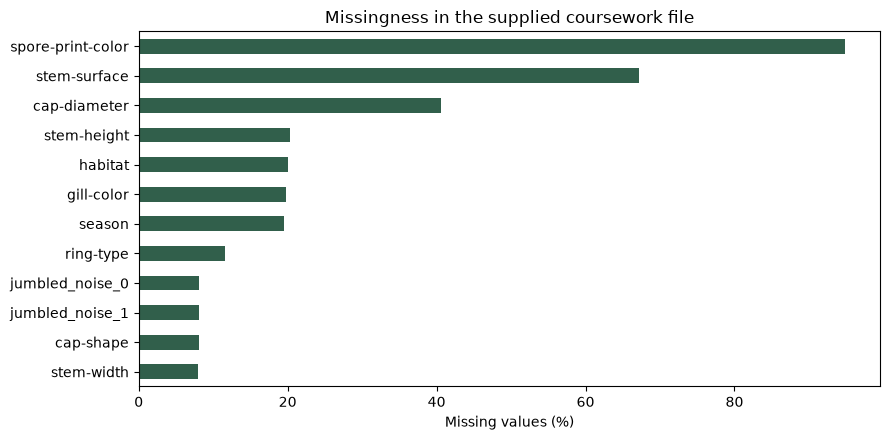

In [2]:
display(frame.dtypes.to_frame('dtype'))
missing = frame.isna().mean().sort_values()*100
display(missing.to_frame('missing_percent'))
fig, ax = plt.subplots(figsize=(9, 4.5))
missing.drop('class').plot.barh(ax=ax, color='#315f4b')
ax.set_xlabel('Missing values (%)')
ax.set_title('Missingness in the supplied coursework file')
fig.tight_layout()
(ROOT/'reports/figures').mkdir(parents=True, exist_ok=True)
fig.savefig(ROOT/'reports/figures/missingness.png', dpi=140)
plt.show()

## Reserve the final test data

We use a reproducible stratified 60/20/20 split. Detailed investigation below uses the training subset. The validation subset is for model selection, and the final test subset remains unused in this pilot.

{'train': 3000, 'validation': 1000, 'test': 1000}


,cap-diameter,stem-height,stem-width
count,1819.000000,2377.000000,2770.000000
mean,7.273068,6.693946,12.854361
std,6.372660,3.508978,10.631651
min,0.500000,0.000000,0.000000
25%,3.840000,4.780000,6.030000
50%,6.180000,5.980000,11.255000
75%,8.740000,7.710000,16.977500
max,57.400000,32.430000,102.480000


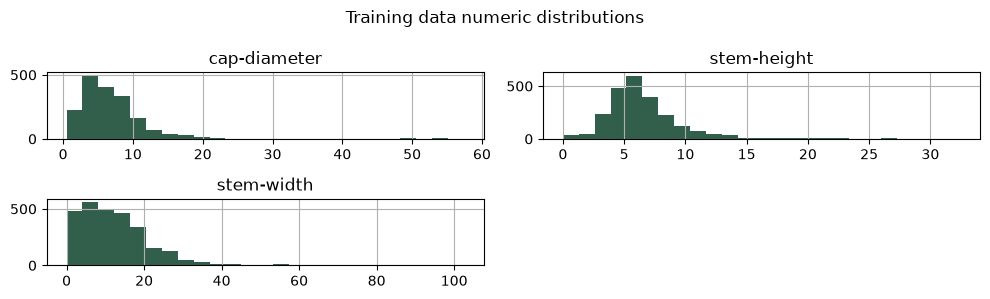

In [3]:
splits = make_split(frame)
training = frame.loc[splits['train']]
print({name: len(indices) for name, indices in splits.items()})
display(training.select_dtypes(include='number').describe())
training.select_dtypes(include='number').hist(figsize=(10, 3), bins=25, color='#315f4b')
plt.suptitle('Training data numeric distributions')
plt.tight_layout()
plt.show()

## Interpretation and next decisions

- `spore-print-color` is about 95% missing. Compare keeping it with a missing category against dropping it, using development folds.
- `stem-surface` is also heavily missing. Investigate whether missingness itself carries a pattern.
- Avoid dropping every incomplete row; quantify how many rows each rule removes and whether class proportions change.
- Compare the two noise columns through a controlled ablation on the same folds.
- Check numeric extremes using training-only plots and document reasons for any treatment.
- The source is hypothetical; species identity is absent. A random split measures performance on similar source rows, not unseen species or real photographs.

The next notebook begins the model comparison. This audit is an initial inspection, not a finished EDA story.